# 04 — Validation (Stage E)

Per `docs/04_feature_detection_design_spec.md` §7:

- **7.1** Distance-to-nearest-well vs. random baseline (N = 200 permutations). Report empirical p-value.
- **7.2** Within-uncertainty recall at 50 m vs. random null.

Inputs: `data/derivatives/candidates/candidates_pads.gpkg`, `data/derivatives/wells_in_tile.gpkg`, `data/derivatives/ground_density.tif`.

Outputs: `data/derivatives/validation/summary_run_<run_id>.md`, appended summary in `docs/analysis_log.md`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from datetime import datetime

PROJECT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DERIV = PROJECT / 'data' / 'derivatives'
CAND  = DERIV / 'candidates'
VAL   = DERIV / 'validation'
LOGS  = PROJECT / 'docs'
VAL.mkdir(parents=True, exist_ok=True)

cand_path = CAND / 'candidates_roads.gpkg'
if not cand_path.exists():
    cand_path = CAND / 'candidates_pads.gpkg'
cand = gpd.read_file(cand_path)
print('loaded', cand_path.name, 'geometry type:', cand.geometry.geom_type.iloc[0])
wells = gpd.read_file(DERIV / 'wells_in_tile.gpkg').to_crs(cand.crs)
assert len(cand) > 0 and len(wells) > 0

with rasterio.open(DERIV / 'ground_density.tif') as ds:
    density = ds.read(1)
    transform = ds.transform
    crs = ds.crs
H, W = density.shape
cs = float(transform.a)
X0, Y1 = transform.c, transform.f
X1 = X0 + W * cs
Y0 = Y1 - H * cs

RUN_ID = str(cand['run_id'].iloc[0]) if 'run_id' in cand.columns and len(cand) else 'unknown'
UNCERT_M = 100.0
DENS_MIN = 1
N_PERM = 200
RNG_SEED = 12345
print(f'candidates: {len(cand)}, wells: {len(wells)}, run_id: {RUN_ID}')

loaded candidates_roads.gpkg geometry type: LineString
candidates: 191, wells: 107, run_id: 20260414T053528Z-1eface


## Observed statistics

In [2]:
from scipy.spatial import cKDTree
well_coords = np.column_stack([wells.geometry.x.values, wells.geometry.y.values])
well_tree = cKDTree(well_coords)

# For each candidate (line or polygon), distance = min(shapely distance to any well).
# Use shapely (handles lines) rather than centroid KD-tree.
def candidate_to_well(geom):
    return float(geom.distance(wells.geometry).min())
obs_d = np.array([candidate_to_well(g) for g in cand.geometry])
obs_median = float(np.median(obs_d))
obs_mean   = float(np.mean(obs_d))
obs_p25    = float(np.percentile(obs_d, 25))
obs_p75    = float(np.percentile(obs_d, 75))

# Recall@UNCERT: well has a candidate whose geometry comes within UNCERT of it.
def well_to_nearest_candidate(pt):
    return float(cand.geometry.distance(pt).min())
w_nc = np.array([well_to_nearest_candidate(g) for g in wells.geometry])
obs_recall = float((w_nc <= UNCERT_M).mean())
obs_recall_n = int((w_nc <= UNCERT_M).sum())

print(f'observed candidate -> nearest-well distances (m):')
print(f'  median {obs_median:.2f}  mean {obs_mean:.2f}  p25 {obs_p25:.2f}  p75 {obs_p75:.2f}')
print(f'observed recall@{UNCERT_M:.0f} m: {obs_recall_n}/{len(wells)} = {obs_recall:.3f}')


observed candidate -> nearest-well distances (m):
  median 42.67  mean 56.74  p25 14.66  p75 72.63
observed recall@100 m: 107/107 = 1.000


## Null baseline — random candidate placements (rejection-sampled on density mask)

In [3]:
valid_cells = np.argwhere(density >= DENS_MIN)
print(f'valid cells: {len(valid_cells):,} / {H*W:,}')

def random_points(n, rng):
    idx = rng.choice(len(valid_cells), size=n, replace=True)
    rc = valid_cells[idx]
    xs = X0 + (rc[:, 1] + rng.random(n)) * cs
    ys = Y1 - (rc[:, 0] + rng.random(n)) * cs
    return np.column_stack([xs, ys])

N_CAND = len(cand)
rng = np.random.default_rng(RNG_SEED)
null_median = np.empty(N_PERM)
null_recall = np.empty(N_PERM)
for k in range(N_PERM):
    rxy = random_points(N_CAND, rng)
    d, _ = well_tree.query(rxy, k=1)
    null_median[k] = np.median(d)
    rtree = cKDTree(rxy)
    wd, _ = rtree.query(well_coords, k=1)
    null_recall[k] = (wd <= UNCERT_M).mean()

p_median = float(np.mean(null_median <= obs_median))
p_recall = float(np.mean(null_recall >= obs_recall))
null_median_stats = (np.percentile(null_median,5), np.percentile(null_median,50), np.percentile(null_median,95))
null_recall_stats = (np.percentile(null_recall,5), np.percentile(null_recall,50), np.percentile(null_recall,95))
print(f'null median (m) p5/p50/p95 = {null_median_stats[0]:.2f} / {null_median_stats[1]:.2f} / {null_median_stats[2]:.2f}')
print(f'null recall    p5/p50/p95 = {null_recall_stats[0]:.3f} / {null_recall_stats[1]:.3f} / {null_recall_stats[2]:.3f}')
print(f'empirical p(median <= obs) = {p_median:.4f}')
print(f'empirical p(recall >= obs) = {p_recall:.4f}')
VERDICT = 'SIGNAL ABOVE CHANCE' if (p_median < 0.05 or p_recall < 0.05) else 'NOT ABOVE CHANCE'
print(f'VERDICT: {VERDICT}')


valid cells: 2,059,697 / 2,250,000


null median (m) p5/p50/p95 = 58.48 / 62.46 / 67.64
null recall    p5/p50/p95 = 0.869 / 0.916 / 0.963
empirical p(median <= obs) = 0.0000
empirical p(recall >= obs) = 0.0000
VERDICT: SIGNAL ABOVE CHANCE


## QA plots

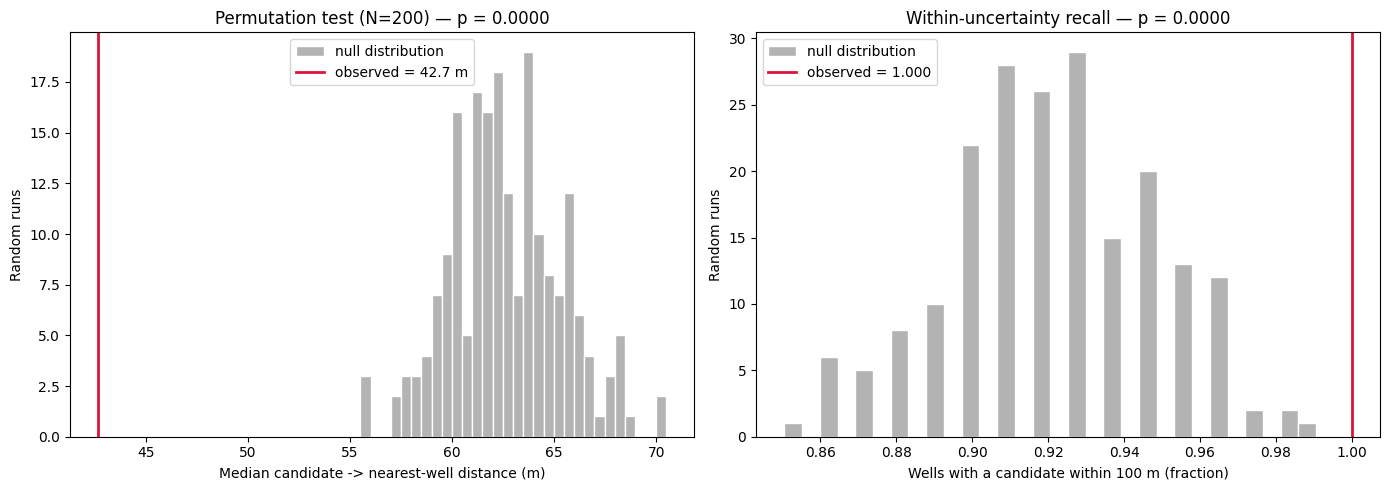

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(null_median, bins=30, color='0.7', edgecolor='white', label='null distribution')
axes[0].axvline(obs_median, color='crimson', lw=2, label=f'observed = {obs_median:.1f} m')
axes[0].set_xlabel('Median candidate -> nearest-well distance (m)')
axes[0].set_ylabel('Random runs')
axes[0].set_title(f'Permutation test (N={N_PERM}) — p = {p_median:.4f}')
axes[0].legend()

axes[1].hist(null_recall, bins=30, color='0.7', edgecolor='white', label='null distribution')
axes[1].axvline(obs_recall, color='crimson', lw=2, label=f'observed = {obs_recall:.3f}')
axes[1].set_xlabel(f'Wells with a candidate within {UNCERT_M:.0f} m (fraction)')
axes[1].set_ylabel('Random runs')
axes[1].set_title(f'Within-uncertainty recall — p = {p_recall:.4f}')
axes[1].legend()
plt.tight_layout(); plt.show()

## Export summary + append to log

In [5]:
NULL_PARQ = VAL / f'nulls_{RUN_ID}.parquet'
pd.DataFrame({'null_median_m': null_median, 'null_recall': null_recall}).to_parquet(NULL_PARQ)

summary_md = (
    f"# Validation summary — run {RUN_ID}\n\n"
    f"Date: {datetime.utcnow():%Y-%m-%d %H:%M UTC}\n\n"
    f"## Observed\n\n"
    f"- Candidates: **{len(cand)}**\n"
    f"- Wells: **{len(wells)}**\n"
    f"- Median candidate -> nearest-well distance: **{obs_median:.2f} m**\n"
    f"- Mean distance: {obs_mean:.2f} m (IQR {obs_p25:.2f} – {obs_p75:.2f})\n"
    f"- Within-{UNCERT_M:.0f} m recall: **{obs_recall_n}/{len(wells)} = {obs_recall:.3f}**\n\n"
    f"## Null baseline (N = {N_PERM} random point sets on density-valid cells)\n\n"
    f"| metric | observed | null p5 | null p50 | null p95 | empirical p |\n"
    f"|---|---:|---:|---:|---:|---:|\n"
    f"| median distance (m) | {obs_median:.2f} | {null_median_stats[0]:.2f} | {null_median_stats[1]:.2f} | {null_median_stats[2]:.2f} | **{p_median:.4f}** |\n"
    f"| within-{UNCERT_M:.0f} m recall | {obs_recall:.3f} | {null_recall_stats[0]:.3f} | {null_recall_stats[1]:.3f} | {null_recall_stats[2]:.3f} | **{p_recall:.4f}** |\n\n"
    f"## Verdict\n\n"
    f"**{('SIGNAL ABOVE CHANCE' if (p_median < 0.05 or p_recall < 0.05) else 'NOT ABOVE CHANCE')}** — threshold p < 0.05 on either metric.\n"
)
SUM = VAL / f'summary_run_{RUN_ID}.md'
SUM.write_text(summary_md, encoding='utf-8')
print('wrote', SUM.name)

log_entry = (
    f"\n## {datetime.utcnow():%Y-%m-%d %H:%M UTC} — Stage E (04_validation)  run {RUN_ID}\n\n"
    f"- Observed median dist: {obs_median:.2f} m;  null p5/p50/p95 = {null_median_stats[0]:.2f}/{null_median_stats[1]:.2f}/{null_median_stats[2]:.2f};  p={p_median:.4f}\n"
    f"- Observed recall@{UNCERT_M:.0f}m: {obs_recall:.3f};  null p5/p50/p95 = {null_recall_stats[0]:.3f}/{null_recall_stats[1]:.3f}/{null_recall_stats[2]:.3f};  p={p_recall:.4f}\n"
    f"- Verdict: **{('SIGNAL ABOVE CHANCE' if (p_median < 0.05 or p_recall < 0.05) else 'NOT ABOVE CHANCE')}**\n"
    f"- Full summary: {SUM.relative_to(PROJECT)}\n"
)
with open(LOGS / 'analysis_log.md', 'a', encoding='utf-8') as f:
    f.write(log_entry)
print(log_entry)

wrote summary_run_20260414T053528Z-1eface.md

## 2026-04-14 05:35 UTC — Stage E (04_validation)  run 20260414T053528Z-1eface

- Observed median dist: 42.67 m;  null p5/p50/p95 = 58.48/62.46/67.64;  p=0.0000
- Observed recall@100m: 1.000;  null p5/p50/p95 = 0.869/0.916/0.963;  p=0.0000
- Verdict: **SIGNAL ABOVE CHANCE**
- Full summary: data\derivatives\validation\summary_run_20260414T053528Z-1eface.md



C:\Users\colto\AppData\Local\Temp\ipykernel_41708\3541152305.py:6: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  f"Date: {datetime.utcnow():%Y-%m-%d %H:%M UTC}\n\n"
C:\Users\colto\AppData\Local\Temp\ipykernel_41708\3541152305.py:26: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  f"\n## {datetime.utcnow():%Y-%m-%d %H:%M UTC} — Stage E (04_validation)  run {RUN_ID}\n\n"
